In [1]:
%load_ext autoreload
%autoreload 2

```{toctree}
:maxdepth: 1
:caption: Contents:

# Walkthrough Example - Temporal Analysis

```{hint}
Before using the `WaveTemporalAnalyzer` class, make sure you have the necessary data and dependencies installed. This example assumes you have time series data from an AQUAlogger and a RBR device.

Users are referred to the THIS LINK for a installation guide of the `oceanicospy` package and its dependencies.
```

# Importing required modules and subpackages

In [2]:
from datetime import datetime, timedelta
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
mpl.rcParams["font.size"] = 12
mpl.rcParams["figure.dpi"] = 150

The subpackage temporal will deal with the temporal analysis of the sea surface elevation data. AQUAlogger and RBR class are also imported to load the sensor data.

In [3]:
from oceanicospy.observations.pressure_sensors import AQUAlogger,RBR
from oceanicospy.analysis import temporal

# Pressure data

In [4]:
measurement_pressure_sensors_paths = ['../data/observations/AQUAlogger/','../data/observations/RBR/']

sampling_AQ = dict(anchoring_depth=1,sensor_height=0.2,sampling_freq=1,burst_length_s=2048,temperature=False,
                            start_time=datetime(2025,5,9,10,0,0),end_time=datetime(2025,5,19,18,0,0)-timedelta(seconds=1))
sampling_RBR = dict(anchoring_depth=1,sensor_height=0.2,sampling_freq=2,burst_length_s=7200,
                            start_time=datetime(2025,5,9,10,0,0),end_time=datetime(2025,5,19,18,0,0)-timedelta(seconds=0.5))

Methods from the observations subpackage are used to load the raw pressure data from the sensors. The data is then cleaned and prepared for the temporal analysis.

In [5]:
sampling_data = [sampling_AQ,sampling_RBR]
metadata_list=['AQ','RBR']
dict_raw_measurements = dict()
dict_clean_measurements = dict()

for idx,measurement_path in enumerate(measurement_pressure_sensors_paths):
    if 'AQ' in measurement_path:
        object_device = AQUAlogger(measurement_path, sampling_data[idx], filename='AQUAlogger_520PT5.csv')
    else:
        object_device = RBR(measurement_path,sampling_data[idx])

    raw_data = object_device.get_raw_records()
    clean_data = object_device.get_clean_records()
    dict_raw_measurements[metadata_list[idx]] = raw_data
    dict_clean_measurements[metadata_list[idx]] = clean_data

In [6]:
dict_clean_measurements['AQ'].head()

,pressure[bar],depth[m],depth_aux[m],burstId,eta[m]
date,,,,,
2025-05-09 10:00:00,1.245722,3.136509,2.307327,1,0.052596
2025-05-09 10:00:01,1.244709,3.124966,2.297273,1,0.041052
2025-05-09 10:00:02,1.237181,3.039040,2.222556,1,-0.044874
2025-05-09 10:00:03,1.243695,3.113418,2.287209,1,0.029503
2025-05-09 10:00:04,1.253249,3.222086,2.382034,1,0.138170


In [7]:
dict_clean_measurements['RBR'].head()

,pressure[bar],depth[m],burstId,eta[m]
date,,,,
2025-05-09 10:00:00.000,1.241829,2.267149,1,0.117985
2025-05-09 10:00:00.500,1.239702,2.246051,1,0.096886
2025-05-09 10:00:01.000,1.235314,2.202530,1,0.053365
2025-05-09 10:00:01.500,1.233978,2.189276,1,0.040110
2025-05-09 10:00:02.000,1.234466,2.194119,1,0.044954


# Using the `WaveTemporalAnalyzer` class

First, we need to instanciate the `WaveTemporalAnalyzer` class, which will allow us to make the temporal analysis for the pressure data. We need to provide the measurement signal and the sampling data as arguments.

`WaveTemporalAnalyzer` will look for measurement signal with a column named "eta[m]", which is the standard name for the sea surface elevation in **oceanicospy**. If the column name is different, it can be specified as an argument when instanciating the class.

In [8]:
help(temporal.WaveTemporalAnalyzer)

Help on class WaveTemporalAnalyzer in module oceanicospy.analysis.temporal:

class WaveTemporalAnalyzer(builtins.object)
 |  WaveTemporalAnalyzer(measured_signal, sampling_data, surface_level_column='eta[m]')
 |  
 |  Methods defined here:
 |  
 |  __init__(self, measured_signal, sampling_data, surface_level_column='eta[m]')
 |      "
 |      Initializes the analysis object with measurement signal and sampling data.
 |      
 |      Parameters
 |      ----------
 |      measurement_signal : array-like
 |          The input signal data to be analyzed.
 |      sampling_data : dict
 |          Dictionary containing sampling parameters with the following keys:
 |              - 'sampling_freq' (float): Sampling frequency of the signal.
 |              - 'anchoring_depth' (float): Depth at which the sensor is anchored.
 |              - 'sensor_height' (float): Height of the sensor above the bottom.
 |              - 'burst_length_s' (float): Duration of each burst in seconds.
 |      surfa

## Zero upcrossing method

In [9]:
wave_params_dfs = dict()
for idx,metadata in enumerate(metadata_list):
    TemporalAnalyzer = temporal.WaveTemporalAnalyzer(dict_clean_measurements[metadata],sampling_data[idx])
    print(type(TemporalAnalyzer))
    wave_params_dfs[metadata_list[idx]] = TemporalAnalyzer.compute_params_from_zero_upcrossing()

<class 'oceanicospy.analysis.temporal.WaveTemporalAnalyzer'>
<class 'oceanicospy.analysis.temporal.WaveTemporalAnalyzer'>


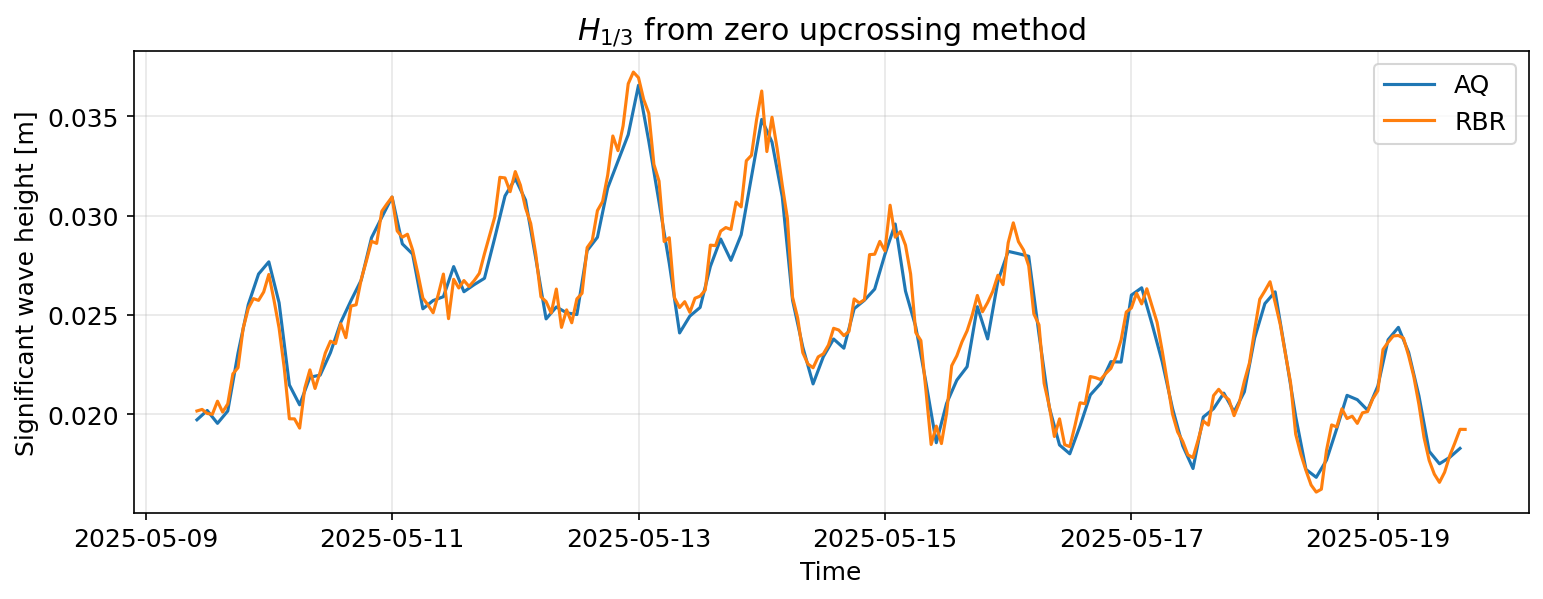

In [10]:
fig,ax = plt.subplots(1,1,figsize=(12,4))

ax.plot(wave_params_dfs['AQ']['H1/3'],label='AQ')
ax.plot(wave_params_dfs['RBR']['H1/3'],label='RBR')
ax.set(ylabel='Significant wave height [m]',xlabel='Time',title='$H_{1/3}$ from zero upcrossing method')
ax.grid(True,alpha=0.3)
ax.legend()
plt.show()

# Empirical mode decomposition (EMD) method

We can also use the EMD method to decompose the sea surface elevation signal into its intrinsic mode functions (IMFs). This can be useful to analyze the different frequency components of the signal.